# GANs from Scratch and in the Wild - 7COM1079 Coursework 2

This notebook is my full submission for Coursework 2. Part 1 builds a GAN from scratch on simple 2D data, and Part 2 works through the three real-world applications: medical scans, network traffic, and hand-drawn sketches. I used PyTorch for the from-scratch models in Part 1 and for the tabular traffic GAN in Part 2.2, and TensorFlow/Keras for the two image models (the OCT scans and the sketches). The two image GANs share one small reusable trainer class so I am not writing the same training loop twice.

| Part | Task | Framework |
|------|------|-----------|
| 1 | GANs from scratch on 2D data (class-based, LayerNorm generator, spectral-norm critic) | PyTorch |
| 2.1 | OCTMNIST medical DCGAN + conditional GAN | TensorFlow/Keras |
| 2.2 | CICIDS 2017 tabular feature-vector GAN + full-day extension | PyTorch |
| 2.3 | QuickDraw sketch DCGAN + extra categories | TensorFlow/Keras |

To keep the figures repeatable I fix the seeds up front: `SEED = 5050` for the PyTorch/NumPy side and `KERAS_SEED = 6060` for TensorFlow. Everything that gets plotted is written into the `results/` folder so the figures are easy to hand in alongside the report.

**Datasets.** OCTMNIST is pulled in automatically through the `medmnist` package, the QuickDraw bitmaps download from Google Cloud Storage, and the eight CICIDS 2017 daily CSV files are picked up automatically, either from the folder this notebook sits in or, failing that, downloaded from Kaggle. The notebook expects the GPU accelerator and internet access to be turned on.

## Setting up the environment (run this before anything else)

This first cell just installs the libraries that are not always already on the runtime. I install PyTorch before anything else so the later installs (medmnist and friends) do not quietly pull in a different build of it. Re-running is fine because pip skips whatever is already satisfied. One thing I ran into: if TensorFlow does not pick up the GPU straight after installing, restarting the kernel once and running again sorts it out.

In [1]:
def quiet_pip(*packages):
    """Install pip packages into the running kernel (quiet, non-fatal)."""
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=False)


# Torch is installed first so the medmnist/data installs never downgrade it.
quiet_pip("torch", "torchvision")
quiet_pip("medmnist", "kagglehub", "requests", "tqdm", "pillow", "matplotlib", "pandas", "scikit-learn", "scipy")
quiet_pip("tensorflow[and-cuda]")     # use "tensorflow" for a CPU-only machine
print("Runtime dependencies in place.")

Runtime dependencies in place.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires nvidia-nccl-cu12==2.27.5; platform_system == "Linux", but you have nvidia-nccl-cu12 2.30.7 which is incompatible.


## Part 1 - GANs from scratch on 2D data with PyTorch
For Part 1 I wrote everything in PyTorch without leaning on a GAN library. Instead of scattering the pieces across free functions I gathered them into one small trainer object, `SpectralGanTrainer`, which owns the generator and critic and exposes `.fit()` and `.synth()`. The generator is an MLP steadied with LayerNorm, the critic is wrapped in spectral normalisation so it cannot overpower the generator, and both train with the non-saturating loss (`BCEWithLogitsLoss`) under a two-step critic schedule with one-sided label smoothing. The same class covers all three tasks: the sine wave, the mixture of Gaussians, and the architecture comparison - I only change the constructor arguments.

In [2]:
import os, math, random
import numpy as np
import scipy.linalg                       # used later by the FID score
import torch
import torch.nn as nn
from torch.nn.utils import spectral_norm
import matplotlib.pyplot as plt

# os / numpy / scipy / matplotlib live here (Part 1 always runs first) and are reused
# by the TensorFlow parts further down.
SEED = 5050


def set_all_seeds(seed=SEED):
    """Pin Python / NumPy / PyTorch RNGs so every figure is reproducible."""
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    np.random.seed(seed); random.seed(seed)
    torch.backends.cudnn.benchmark = False; torch.backends.cudnn.deterministic = True


set_all_seeds()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Torch {torch.__version__} using {DEVICE} (results dir {RESULTS_DIR})")


def _save_show(fig, filename):
    plt.show()


def plot_clouds(real_xy, fake_xy, title, filename=None):
    """Overlay a real vs generated 2D point cloud."""
    fig = plt.figure(figsize=(6, 6))
    plt.scatter(real_xy[:, 0], real_xy[:, 1], s=6, alpha=0.4, label="Real", color="#2c7fb8")
    plt.scatter(fake_xy[:, 0], fake_xy[:, 1], s=6, alpha=0.4, label="Generated", color="#d95f0e")
    plt.title(title); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(alpha=0.2)
    plt.gca().set_aspect("equal", adjustable="datalim")
    _save_show(fig, filename)


def plot_curves(critic_hist, gen_hist, title, filename=None):
    """Plot the critic vs generator loss traces."""
    fig = plt.figure(figsize=(8, 4))
    plt.plot(critic_hist, label="Critic", color="#2c7fb8", alpha=0.85)
    plt.plot(gen_hist, label="Generator", color="#d95f0e", alpha=0.85)
    plt.title(title); plt.xlabel("iteration"); plt.ylabel("BCE loss"); plt.legend(); plt.grid(alpha=0.2)
    _save_show(fig, filename)

Torch 2.10.0+cu128 using cuda (results dir results)


### 1.1 - The configurable GAN and its target distributions

In [3]:
Z_DIM = 24   # latent width for the from-scratch generators

def draw_sine(n, span=(-math.pi, math.pi)):
    """Points on y = sin(x); assembled in NumPy, then handed back as a float tensor."""
    lo, hi = span
    xs = np.random.uniform(lo, hi, size=(n, 1)).astype(np.float32)
    pts = np.concatenate([xs, np.sin(xs)], axis=1)
    return torch.from_numpy(pts)

def draw_gaussian_grid(n, grid=3, spacing=2.0, spread=0.09):
    """Mixture of Gaussians on a grid x grid lattice (a mode-coverage stress test)."""
    offsets = (np.arange(grid, dtype=np.float32) - (grid - 1) / 2.0) * spacing
    centres = np.array([[cx, cy] for cx in offsets for cy in offsets], dtype=np.float32)
    picks = centres[np.random.randint(0, len(centres), size=n)]
    pts = picks + np.random.randn(n, 2).astype(np.float32) * spread
    return torch.from_numpy(pts)

# Activations are stored as (class, kwargs) pairs and instantiated on demand, so each
# network gets its own fresh module rather than a shared instance.
_ACTIVATIONS = {
    "relu": (nn.ReLU, {}),
    "lrelu": (nn.LeakyReLU, {"negative_slope": 0.2}),
    "gelu": (nn.GELU, {}),
    "elu": (nn.ELU, {}),
    "tanh": (nn.Tanh, {}),
    "selu": (nn.SELU, {}),
}

def new_activation(key):
    """Instantiate a fresh activation module from its short name."""
    try:
        cls, kwargs = _ACTIVATIONS[key]
    except KeyError as exc:
        raise ValueError(f"unsupported activation {key!r}") from exc
    return cls(**kwargs)


The generator uses LayerNorm between its layers and the critic is wrapped in spectral normalisation; together those are the main things keeping training stable for this set.

In [4]:
from collections import OrderedDict

def stack_dense(dims, activation, layernorm=False, spectral=False):
    """Assemble an MLP from consecutive widths in `dims`. Hidden layers get the chosen
    activation (and optional LayerNorm); the final projection is left linear so the
    output is unbounded. Optional spectral norm keeps the critic Lipschitz-bounded."""
    seq = OrderedDict()
    for idx in range(len(dims) - 1):
        linear = nn.Linear(dims[idx], dims[idx + 1])
        seq[f"fc{idx}"] = spectral_norm(linear) if spectral else linear
        if idx < len(dims) - 2:
            if layernorm:
                seq[f"ln{idx}"] = nn.LayerNorm(dims[idx + 1])
            seq[f"act{idx}"] = new_activation(activation)
    return nn.Sequential(seq)

class SpectralGanTrainer:
    """From-scratch 2D GAN: a LayerNorm generator against a spectral-normalised critic.
    Trained with the non-saturating BCE objective, a two-step critic schedule, and
    one-sided label smoothing. The per-update losses live in the private helpers."""

    def __init__(self, gen_widths=(128, 128), critic_widths=(128, 128),
                 gen_act="gelu", critic_act="lrelu", smooth=0.9):
        self.G = stack_dense([Z_DIM, *gen_widths, 2], gen_act, layernorm=True).to(DEVICE)
        self.D = stack_dense([2, *critic_widths, 1], critic_act, spectral=True).to(DEVICE)
        self.loss_fn = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def _noise(self, k):
        return torch.randn(k, Z_DIM, device=DEVICE)

    def _critic_loss(self, real):
        k = real.size(0)
        with torch.no_grad():
            fake = self.G(self._noise(k))
        real_target = torch.full((k, 1), self.smooth, device=DEVICE)
        fake_target = torch.zeros(k, 1, device=DEVICE)
        return self.loss_fn(self.D(real), real_target) + self.loss_fn(self.D(fake), fake_target)

    def _gen_loss(self, k):
        minted = self.G(self._noise(k))
        return self.loss_fn(self.D(minted), torch.ones(k, 1, device=DEVICE))

    def fit(self, draw_fn, steps=6000, batch=256, lr=2e-4, n_critic=2, report=2000):
        opt_g = torch.optim.Adam(self.G.parameters(), lr=lr, betas=(0.5, 0.999))
        opt_d = torch.optim.Adam(self.D.parameters(), lr=lr, betas=(0.5, 0.999))
        d_trace, g_trace = [], []
        for step in range(1, steps + 1):
            for _ in range(n_critic):
                real = draw_fn(batch).to(DEVICE)
                d_loss = self._critic_loss(real)
                opt_d.zero_grad(set_to_none=True); d_loss.backward(); opt_d.step()
            g_loss = self._gen_loss(batch)
            opt_g.zero_grad(set_to_none=True); g_loss.backward(); opt_g.step()
            d_trace.append(float(d_loss)); g_trace.append(float(g_loss))
            if step == 1 or step % report == 0:
                print(f"step {step:>5}/{steps} | critic={float(d_loss):.4f} | generator={float(g_loss):.4f}")
        return d_trace, g_trace

    @torch.no_grad()
    def synth(self, n):
        self.G.eval()
        out = self.G(self._noise(n)).cpu().numpy()
        self.G.train()
        return out


### 1.2 - Task 1: the sine-wave GAN revisited

/tmp/ipykernel_678647/954119013.py:55: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  d_trace.append(float(d_loss)); g_trace.append(float(g_loss))


step     1/6000 | critic=1.3768 | generator=0.7738
step  2000/6000 | critic=1.3760 | generator=0.8011
step  4000/6000 | critic=1.3761 | generator=0.7997
step  6000/6000 | critic=1.3765 | generator=0.8009


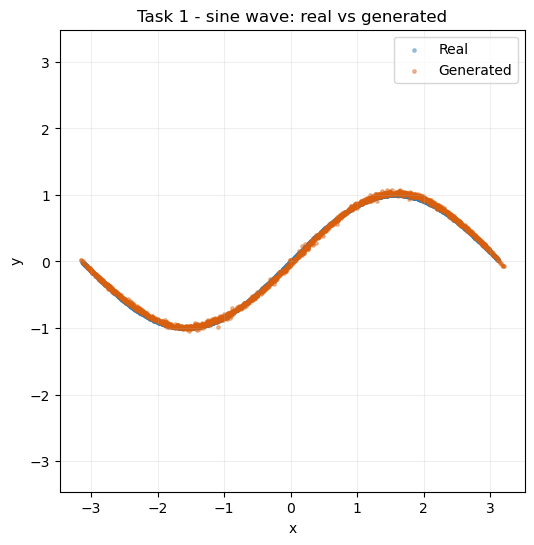

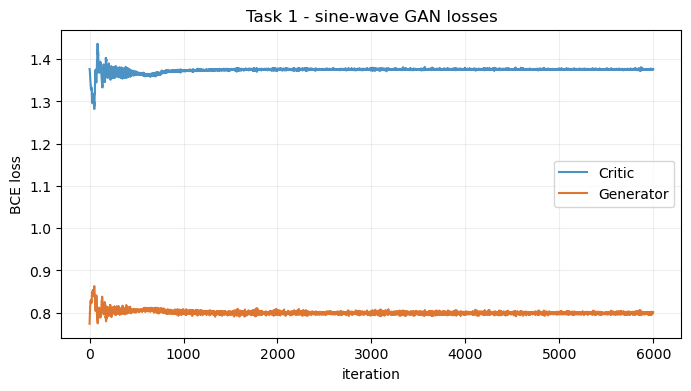

In [5]:
set_all_seeds()
sine_model = SpectralGanTrainer()
sine_d_trace, sine_g_trace = sine_model.fit(draw_sine, steps=6000)
plot_clouds(draw_sine(2000).numpy(), sine_model.synth(2000),
            "Task 1 - sine wave: real vs generated", None)
plot_curves(sine_d_trace, sine_g_trace, "Task 1 - sine-wave GAN losses", None)


### 1.3 - Task 2: a nine-mode mixture of Gaussians
For Task 2 the brief lets me choose a new 2D distribution, and I went with a mixture of Gaussians arranged on a 3x3 lattice - nine blobs spread across the plane. It is a good stress test for mode coverage because the generator has to reach every blob rather than collapse onto one or two. This one gets a slightly longer run (8000 steps).

step     1/8000 | critic=1.3746 | generator=0.7758
step  2000/8000 | critic=1.3504 | generator=0.8170
step  4000/8000 | critic=1.3424 | generator=0.8219
step  6000/8000 | critic=1.3358 | generator=0.8224
step  8000/8000 | critic=1.3458 | generator=0.8203


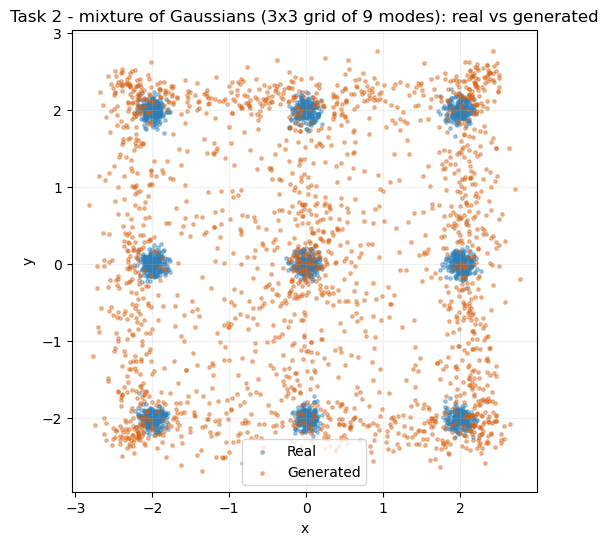

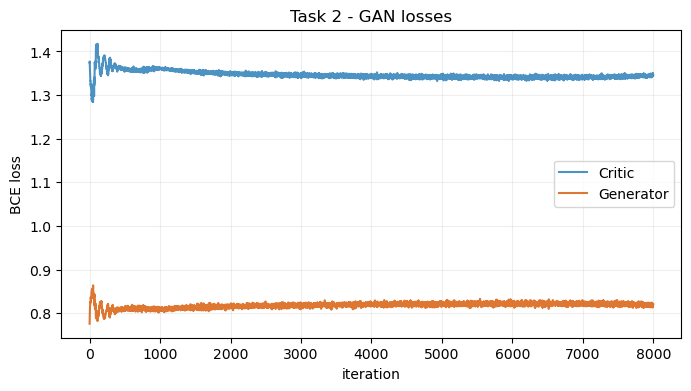

In [6]:
set_all_seeds()
grid_model = SpectralGanTrainer()
grid_d_trace, grid_g_trace = grid_model.fit(draw_gaussian_grid, steps=8000)
plot_clouds(draw_gaussian_grid(2000).numpy(), grid_model.synth(2000),
            "Task 2 - mixture of Gaussians (3x3 grid of 9 modes): real vs generated", None)
plot_curves(grid_d_trace, grid_g_trace, "Task 2 - GAN losses", None)


### 1.4 - Task 3: an architecture sweep and comparison

For the architecture change I compared a baseline generator (2 hidden layers, LeakyReLU) against a deeper modified one (3 hidden layers, GELU). Both are trained the same way on the mixture of Gaussians so the comparison is fair, and I plot the two generated point clouds side by side.

step     1/8000 | critic=1.3760 | generator=0.7754
step  2000/8000 | critic=1.3462 | generator=0.8193
step  4000/8000 | critic=1.3431 | generator=0.8214
step  6000/8000 | critic=1.3474 | generator=0.8177
step  8000/8000 | critic=1.3608 | generator=0.8085
step     1/8000 | critic=1.3909 | generator=0.7330
step  2000/8000 | critic=1.3947 | generator=0.7772
step  4000/8000 | critic=1.3695 | generator=0.7967
step  6000/8000 | critic=1.3626 | generator=0.8068
step  8000/8000 | critic=1.3671 | generator=0.8025


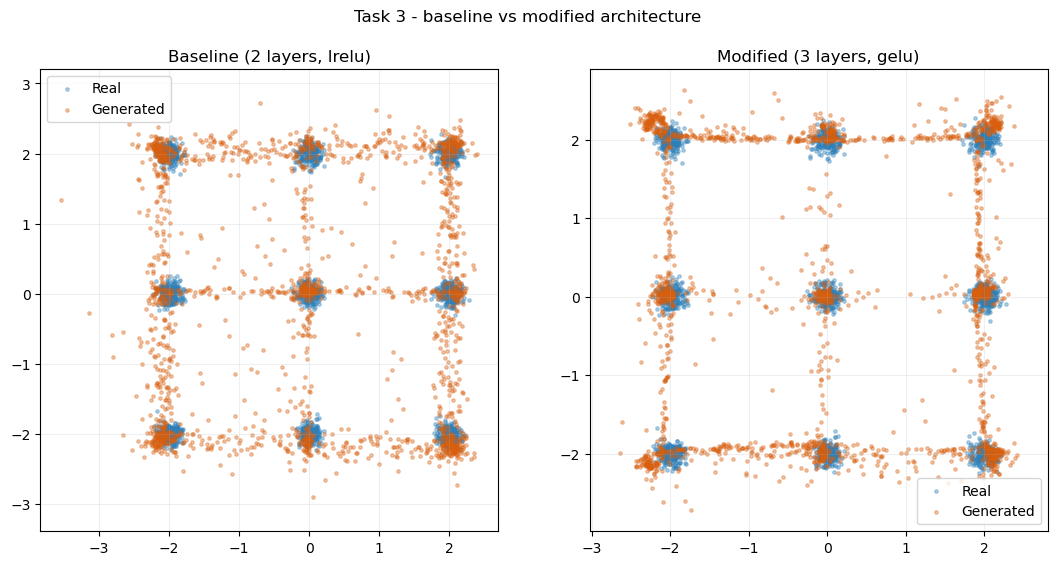

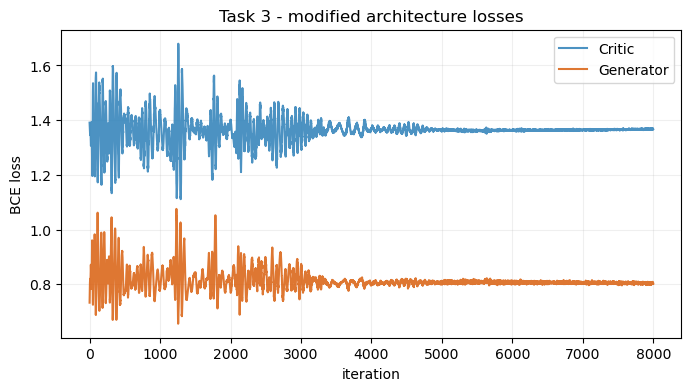

In [7]:
# Baseline: 2 hidden layers with LeakyReLU.  Modified: deeper (3 layers) with GELU.
set_all_seeds()
baseline = SpectralGanTrainer(gen_widths=(128, 128), gen_act="lrelu")
base_d_trace, base_g_trace = baseline.fit(draw_gaussian_grid, steps=8000)
set_all_seeds()
deeper = SpectralGanTrainer(gen_widths=(192, 192, 192), gen_act="gelu")
deep_d_trace, deep_g_trace = deeper.fit(draw_gaussian_grid, steps=8000)
truth = draw_gaussian_grid(2000).numpy()
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, sample, name in ((axes[0], baseline.synth(2000), "Baseline (2 layers, lrelu)"),
                         (axes[1], deeper.synth(2000), "Modified (3 layers, gelu)")):
    ax.scatter(truth[:, 0], truth[:, 1], s=6, alpha=0.35, label="Real", color="#2c7fb8")
    ax.scatter(sample[:, 0], sample[:, 1], s=6, alpha=0.35, label="Generated", color="#d95f0e")
    ax.set_title(name); ax.legend(); ax.grid(alpha=0.2); ax.set_aspect("equal", adjustable="datalim")
fig.suptitle("Task 3 - baseline vs modified architecture")
_save_show(fig, None)
plot_curves(deep_d_trace, deep_g_trace, "Task 3 - modified architecture losses", None)


### 1.5 - Part 1 takeaways
**Task 1 (sine wave).** The generated points line up closely with the sine curve, and the losses stay in a stable band right through training, with no sign of the training diverging or collapsing. The critic settling near the balanced point is roughly where a well-behaved critic ends up once it can no longer easily tell real from generated, which is what I was after.
**Task 2 (mixture of 9 Gaussians on a 3x3 grid).** This target is harder than the sine because it is genuinely nine separate blobs rather than one connected line. Even so the losses stay stable, and the generator reaches all nine modes rather than collapsing onto one or two, although the clusters are not all equally full - a mild version of the mode-imbalance GANs are known for on multi-modal data.
**Task 3 (architecture change).** The shallow LeakyReLU baseline and the deeper GELU generator finish at almost the same losses, so the difference is mostly visual: the deeper generator gives slightly cleaner, tighter clusters. Any stray points sitting between the modes are just the continuous generator bridging the gaps between the disconnected blobs, which is expected here rather than a fault.
Across the three runs the critic settled around 1.34-1.38 and the generator around 0.80-0.82, close to the balanced region expected for this non-saturating loss (critic near 2ln2 = 1.386).

## Keras backend setup and reusable training helpers

This cell sets up the TensorFlow side that the two image GANs use. It seeds TensorFlow (`KERAS_SEED`), turns on GPU memory growth so TF does not grab the whole card at once, and defines the utilities they reuse: the loss-curve plot, a `to_dataset` helper, the `GanTrainer` class (a `keras.Model` subclass whose `train_step` runs the full critic-then-generator update), and a snapshot callback for watching samples develop. Because the OCT and sketch models both reuse `GanTrainer`, each is trained with a plain `model.fit` call. The traffic GAN in Part 2.2 is separate and written in PyTorch, so it does not use any of this. The image-specific helpers, FID and the sample grids, are in the next two cells.

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# os / numpy / matplotlib come from the Part 1 setup, which always runs first.
KERAS_SEED = 6060


def seed_keras(seed=KERAS_SEED):
    """Seed the Python-hash, NumPy and TensorFlow RNGs."""
    import random as _rng
    tf.random.set_seed(seed); np.random.seed(seed); _rng.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


seed_keras()

# Grow GPU memory on demand instead of grabbing the whole card (PyTorch shares it here).
for _device in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_device, True)
    except RuntimeError as _e:
        print("memory-growth note:", _e)

try:
    RESULTS_DIR
except NameError:
    RESULTS_DIR = "results"; os.makedirs(RESULTS_DIR, exist_ok=True)

print("TensorFlow version", tf.__version__, "| GPU devices:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1785755071.796610  678647 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.21.0 | GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
LOGIT_BCE = keras.losses.BinaryCrossentropy(from_logits=True)

def plot_loss_history(d_losses, g_losses, title, filename=None):
    """Line plot of critic vs generator loss (per epoch or per step)."""
    fig, ax = plt.subplots(figsize=(8, 4))
    xs = range(1, len(d_losses) + 1)
    ax.plot(xs, d_losses, label="Critic", color="#2c7fb8", alpha=0.85)
    ax.plot(xs, g_losses, label="Generator", color="#d95f0e", alpha=0.85)
    ax.set(title=title, xlabel="epoch", ylabel="BCE loss")
    ax.legend(); ax.grid(alpha=0.2)
    plt.show()

def to_dataset(arrays, batch_size, labels=None):
    """Shuffled, batched tf.data pipeline over in-memory tensors (images or vectors)."""
    payload = arrays if labels is None else (arrays, labels)
    pipeline = tf.data.Dataset.from_tensor_slices(payload)
    pipeline = pipeline.shuffle(min(len(arrays), 10000), reshuffle_each_iteration=True)
    return pipeline.batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

class GanTrainer(keras.Model):
    """Reusable adversarial trainer (keras.Model). The critic update and the generator
    update each live in their own helper, so train_step simply runs them in turn and
    every image model is trained through a plain model.fit()."""

    def __init__(self, generator, critic, latent_dim):
        super().__init__()
        self.generator = generator
        self.critic = critic
        self.latent_dim = latent_dim
        self._d_metric = keras.metrics.Mean(name="d_loss")
        self._g_metric = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self._d_metric, self._g_metric]

    def compile(self, g_optimizer, d_optimizer, loss_fn):
        super().compile()
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn

    def _latent(self, rows):
        return tf.random.normal((rows, self.latent_dim))

    def _step_critic(self, real):
        rows = tf.shape(real)[0]
        fake = self.generator(self._latent(rows), training=True)
        with tf.GradientTape() as tape:
            score_real = self.critic(real, training=True)
            score_fake = self.critic(fake, training=True)
            loss = (self.loss_fn(tf.ones_like(score_real) * 0.9, score_real)
                    + self.loss_fn(tf.zeros_like(score_fake), score_fake))
        self.d_optimizer.apply_gradients(
            zip(tape.gradient(loss, self.critic.trainable_variables), self.critic.trainable_variables))
        return loss

    def _step_generator(self, rows):
        with tf.GradientTape() as tape:
            fake = self.generator(self._latent(rows), training=True)
            fooled = self.critic(fake, training=True)
            loss = self.loss_fn(tf.ones_like(fooled), fooled)
        self.g_optimizer.apply_gradients(
            zip(tape.gradient(loss, self.generator.trainable_variables), self.generator.trainable_variables))
        return loss

    def train_step(self, real_data):
        real = real_data[0] if isinstance(real_data, (tuple, list)) else real_data
        d_loss = self._step_critic(real)
        g_loss = self._step_generator(tf.shape(real)[0])
        self._d_metric.update_state(d_loss)
        self._g_metric.update_state(g_loss)
        return {"d_loss": self._d_metric.result(), "g_loss": self._g_metric.result()}

class SampleSnapshot(keras.callbacks.Callback):
    """Capture a fixed-noise grid of generated images at a handful of epochs."""

    def __init__(self, generator, latent_dim, epochs, n=16):
        super().__init__()
        self.generator = generator
        self.checkpoints = sorted({int(round(v)) for v in np.linspace(1, epochs, 5)})
        self.noise = tf.random.normal((n, latent_dim))
        self.frames = []

    def on_epoch_end(self, epoch, logs=None):
        step = epoch + 1
        if step in self.checkpoints:
            self.frames.append((step, self.generator(self.noise, training=False).numpy()))

def fit_image_gan(generator, critic, images_signed, epochs, latent_dim, tag, batch_size=128):
    """Train an image GAN through GanTrainer.fit and snapshot the generator across epochs."""
    seed_keras()
    trainer = GanTrainer(generator, critic, latent_dim)
    make_adam = lambda: keras.optimizers.Adam(2e-4, beta_1=0.5)
    trainer.compile(g_optimizer=make_adam(), d_optimizer=make_adam(), loss_fn=LOGIT_BCE)
    watcher = SampleSnapshot(generator, latent_dim, epochs)
    record = trainer.fit(to_dataset(images_signed, batch_size), epochs=epochs,
                         callbacks=[watcher], verbose=2, shuffle=False)
    show_epochs(watcher.frames, f"{tag} - samples across epochs", None)
    return generator, record.history["d_loss"], record.history["g_loss"]


### Keras image utilities: InceptionV3 FID and preview grids

The three image models share these helpers. FID is computed from the pooled features of an ImageNet-pretrained InceptionV3. Because the scans and sketches are single-channel, I repeat them to three channels and resize up to 299x299 before feeding them in, which is what Inception expects.

In [10]:
class FrechetInception:
    """ImageNet InceptionV3 pooled-feature extractor used for the FID score."""

    def __init__(self):
        self.net = keras.applications.InceptionV3(
            include_top=False, pooling="avg", weights="imagenet")

    def embed(self, images_signed, batch=64):
        """(N, H, W, 1|3) images in [-1, 1] -> (N, 2048) InceptionV3 features."""
        arr = np.asarray(images_signed, dtype=np.float32)
        feats = []
        for start in range(0, len(arr), batch):
            window = arr[start:start + batch]
            window = (window + 1.0) * 127.5
            if window.shape[-1] == 1:
                window = np.repeat(window, 3, axis=-1)
            window = tf.image.resize(window, (299, 299))
            window = keras.applications.inception_v3.preprocess_input(window)
            feats.append(np.asarray(self.net.predict(window, verbose=0)))
        return np.concatenate(feats, axis=0)

def frechet_distance(real_feats, fake_feats, eps=1e-6):
    """Frechet distance between two Gaussian-approximated feature sets (lower = closer)."""
    mu1, mu2 = real_feats.mean(axis=0), fake_feats.mean(axis=0)
    sigma1 = np.cov(real_feats, rowvar=False)
    sigma2 = np.cov(fake_feats, rowvar=False)
    mean_term = np.sum((mu1 - mu2) ** 2)
    covmean = scipy.linalg.sqrtm(sigma1.dot(sigma2))
    if isinstance(covmean, tuple):
        covmean = covmean[0]
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = scipy.linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))
        if isinstance(covmean, tuple):
            covmean = covmean[0]
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(mean_term + np.trace(sigma1 + sigma2 - 2.0 * covmean))

def report_fid(scorer, real_signed, fake_signed, tag, sample=2000):
    """Compute and print the FID between a real image array and generated images."""
    take = np.random.permutation(len(real_signed))[:sample]
    real_feats = scorer.embed(real_signed[take])
    fake_feats = scorer.embed(fake_signed[:sample])
    value = frechet_distance(real_feats, fake_feats)
    print(f"{tag}: FID = {value:.2f}")
    return value


In [11]:
def _montage(images_signed, cols=8, rows=8):
    """Tile (N, H, W, 1) images in [-1, 1] into one [0, 1] canvas for imshow."""
    imgs = np.asarray(images_signed)[: cols * rows]
    imgs = (imgs.clip(-1, 1) + 1.0) / 2.0
    if imgs.ndim == 4:
        imgs = imgs[..., 0]
    n_rows = int(np.ceil(len(imgs) / cols))
    h, w = imgs.shape[1], imgs.shape[2]
    grid = np.ones((n_rows * cols, h, w), dtype=np.float32)
    grid[:len(imgs)] = imgs
    return grid.reshape(n_rows, cols, h, w).transpose(0, 2, 1, 3).reshape(n_rows * h, cols * w)

def _draw_canvas(canvas, title, filename):
    """Render one greyscale canvas (already tiled) and optionally save it to results/."""
    plt.figure(figsize=(8, 8))
    plt.imshow(canvas, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def _hstack_with_gap(panels, gap=4):
    """Glue equal-height canvases into a single wide canvas separated by white gaps."""
    stitched = panels[0]
    for panel in panels[1:]:
        divider = np.ones((stitched.shape[0], gap), dtype=np.float32)
        stitched = np.concatenate([stitched, divider, panel], axis=1)
    return stitched

def show_samples(images_signed, title, filename=None, cols=8):
    _draw_canvas(_montage(images_signed, cols=cols), title, filename)

def show_real_fake(real_signed, fake_signed, title, filename=None):
    # Real grid and generated grid laid side by side on one canvas (left = real).
    canvas = _hstack_with_gap([_montage(real_signed, cols=8), _montage(fake_signed, cols=8)])
    _draw_canvas(canvas, f"{title}  (left: real | right: generated)", filename)

def show_epochs(frames, title, filename=None):
    if not frames:
        return
    canvas = _hstack_with_gap([_montage(batch, cols=4) for _, batch in frames])
    labels = ", ".join(str(epoch_no) for epoch_no, _ in frames)
    _draw_canvas(canvas, f"{title}  (epochs {labels})", filename)


# Part 2.1 - Synthesising OCT retina scans with a Keras DCGAN
Here I build a DCGAN for the OCTMNIST retinal scans. The generator is a stack of strided transposed convolutions (`Conv2DTranspose`) that projects the latent vector to a 4x4 feature map and doubles it up to 32x32, and the critic is a stack of strided convolutions with BatchNorm, dropout and a global-average-pooled logit. Rather than a bespoke training loop, it is trained through the shared `GanTrainer` class via `model.fit`, for 40 epochs with a latent dimension of 128. The 28x28 scans are padded out to 32x32 with a black border rather than interpolated. After training I track the losses, put real and generated scans side by side, report FID, and then add a conditional GAN so I can ask for a specific class on demand.

In [12]:
OCT_LATENT = 128
OCT_EPOCHS = 40
print(f"OCT DCGAN config -> latent {OCT_LATENT}, epochs {OCT_EPOCHS}")


OCT DCGAN config -> latent 128, epochs 40


## 2.1.1 - A first look at OCTMNIST

I0000 00:00:1785755075.014375  678647 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20707 MB memory:  -> device: 0, name: NVIDIA A10G, pci bus id: 0000:00:1e.0, compute capability: 8.6


OCT images: (97477, 32, 32, 1) | classes: {'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}


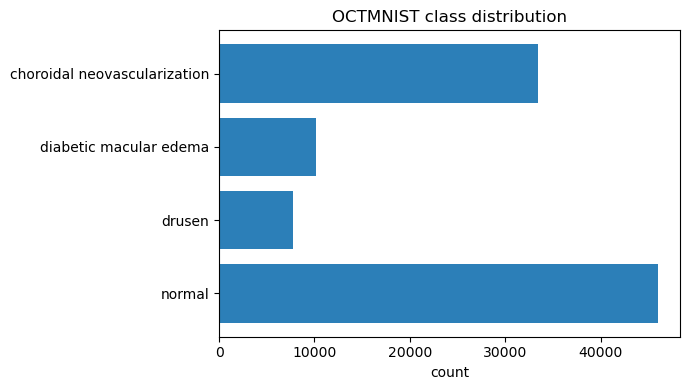

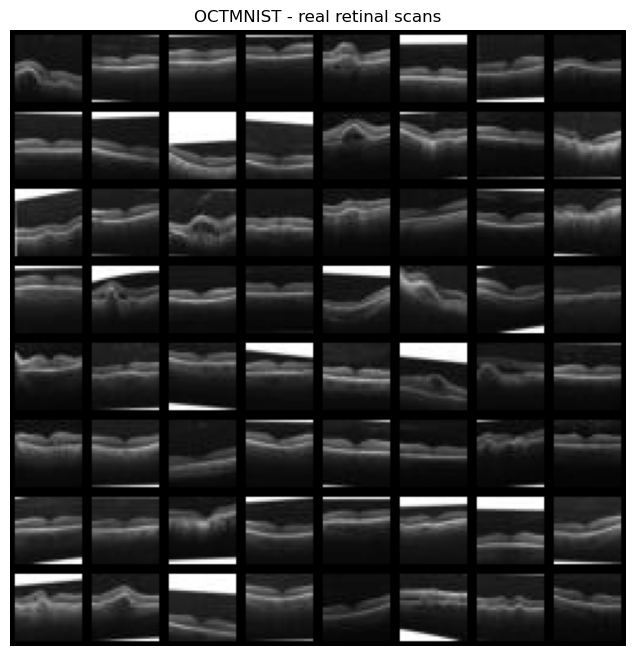

In [13]:
from medmnist import OCTMNIST, INFO
oct_meta = INFO["octmnist"]
OCT_CLASS_NAMES = oct_meta["label"]
OCT_NUM_CLASSES = len(OCT_CLASS_NAMES)

def load_octmnist(pad=2):
    """Fetch OCTMNIST(train), scale to [-1, 1], and pad the 28x28 scans out to 32x32
    with a black (-1) border instead of interpolating them up."""
    ds = OCTMNIST(split="train", download=True)
    signed = ds.imgs.astype("float32")[..., None] / 127.5 - 1.0        # (N, 28, 28, 1)
    border = [[0, 0], [pad, pad], [pad, pad], [0, 0]]
    padded = tf.pad(signed, border, constant_values=-1.0)              # -> (N, 32, 32, 1)
    return padded.numpy(), ds.labels.reshape(-1).astype("int32")

oct_images, oct_labels = load_octmnist()
print("OCT images:", oct_images.shape, "| classes:", OCT_CLASS_NAMES)

# Class balance as a horizontal bar chart.
_present, _counts = np.unique(oct_labels, return_counts=True)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh([OCT_CLASS_NAMES[str(int(v))] for v in _present], _counts, color="#2c7fb8")
ax.set(title="OCTMNIST class distribution", xlabel="count")
ax.invert_yaxis()
fig.tight_layout()
plt.show()
show_samples(oct_images[:64], "OCTMNIST - real retinal scans", None)


## 2.1.2 - Generator and discriminator with the Functional API
Both networks use the Keras Functional API. The generator projects the latent vector to a 4x4x512 feature map and grows it to 32x32 with three strided `Conv2DTranspose` blocks, finishing on a tanh so the output sits in [-1, 1]. The critic mirrors that with strided `Conv2D` layers, BatchNorm and dropout, and reduces to a single logit through global average pooling instead of a flatten.

In [14]:
def dcgan_generator_body(x):
    """Shared OCT DCGAN trunk: project a feature vector to a 4x4x512 map and grow it to
    32x32x1 with three strided Conv2DTranspose blocks. Used by both the plain and the
    conditional OCT generator - only what feeds the projection differs."""
    x = layers.Dense(4 * 4 * 512, use_bias=False)(x)
    x = layers.Reshape((4, 4, 512))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    for filters in (256, 128, 64):                                   # 4 -> 8 -> 16 -> 32
        x = layers.Conv2DTranspose(filters, 4, strides=2, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    return layers.Conv2D(1, 3, padding="same", activation="tanh")(x)

def oct_generator_net(latent_dim):
    """DCGAN generator built from strided transposed convolutions: (latent,) -> (32, 32, 1).
    Projects the latent to a 4x4 map and doubles it three times up to 32x32."""
    noise = keras.Input(shape=(latent_dim,), name="z")
    image = dcgan_generator_body(noise)
    return keras.Model(noise, image, name="scan_generator")

def oct_critic_net():
    """DCGAN critic: strided Conv2D + BatchNorm + dropout, pooled to a single logit."""
    image = keras.Input(shape=(32, 32, 1), name="image")
    x = image
    for i, filters in enumerate((64, 128, 256)):                     # 32 -> 16 -> 8 -> 4
        x = layers.Conv2D(filters, 4, strides=2, padding="same")(x)
        if i > 0:
            x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(0.3)(x)
    x = layers.GlobalAveragePooling2D()(x)
    logit = layers.Dense(1)(x)
    return keras.Model(image, logit, name="scan_critic")

oct_generator = oct_generator_net(OCT_LATENT)
oct_critic = oct_critic_net()
oct_generator.summary()
oct_critic.summary()


Model: "scan_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z (InputLayer)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8192)           │     1,048,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,505 (14.52 MB)

 Trainable params: 3,803,585 (14.51 MB)

 Non-trainable params: 1,920 (7.50 KB)

Model: "scan_critic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 658,625 (2.51 MB)

 Trainable params: 657,857 (2.51 MB)

 Non-trainable params: 768 (3.00 KB)

## 2.1.3 - Running the shared GanTrainer

The OCT DCGAN is trained with the reusable `GanTrainer` class from the setup section, called through `fit_image_gan` (which also snapshots the generator at a few epochs). The same trainer is reused unchanged for the traffic and sketch GANs later on.

Epoch 1/40


I0000 00:00:1785755082.105824  680015 service.cc:153] XLA service 0x7fe7b5690050 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785755082.105856  680015 service.cc:161]   StreamExecutor [0]: NVIDIA A10G, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1785755082.217796  680015 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785755082.959445  680015 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1785755083.308106  680015 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7235__.80
I0000 00:00:1785755100.075369  680015 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


761/761 - 33s - 43ms/step - d_loss: 0.9825 - g_loss: 1.3393
Epoch 2/40
761/761 - 11s - 14ms/step - d_loss: 1.3111 - g_loss: 0.9085
Epoch 3/40
761/761 - 11s - 14ms/step - d_loss: 1.3492 - g_loss: 0.8589
Epoch 4/40
761/761 - 11s - 14ms/step - d_loss: 1.3318 - g_loss: 0.9014
Epoch 5/40
761/761 - 11s - 14ms/step - d_loss: 1.3400 - g_loss: 0.8943
Epoch 6/40
761/761 - 11s - 14ms/step - d_loss: 1.3508 - g_loss: 0.8709
Epoch 7/40
761/761 - 11s - 14ms/step - d_loss: 1.3463 - g_loss: 0.8745
Epoch 8/40
761/761 - 11s - 14ms/step - d_loss: 1.3511 - g_loss: 0.8688
Epoch 9/40
761/761 - 11s - 14ms/step - d_loss: 1.3521 - g_loss: 0.8650
Epoch 10/40
761/761 - 11s - 14ms/step - d_loss: 1.3514 - g_loss: 0.8606
Epoch 11/40
761/761 - 11s - 14ms/step - d_loss: 1.3526 - g_loss: 0.8591
Epoch 12/40
761/761 - 11s - 14ms/step - d_loss: 1.3533 - g_loss: 0.8583
Epoch 13/40
761/761 - 11s - 14ms/step - d_loss: 1.3505 - g_loss: 0.8565
Epoch 14/40
761/761 - 11s - 14ms/step - d_loss: 1.3492 - g_loss: 0.8593
Epoch 15/40


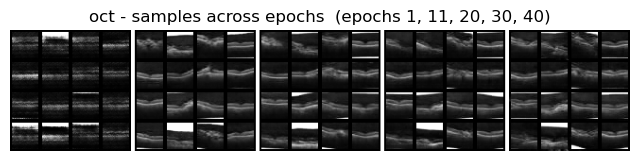

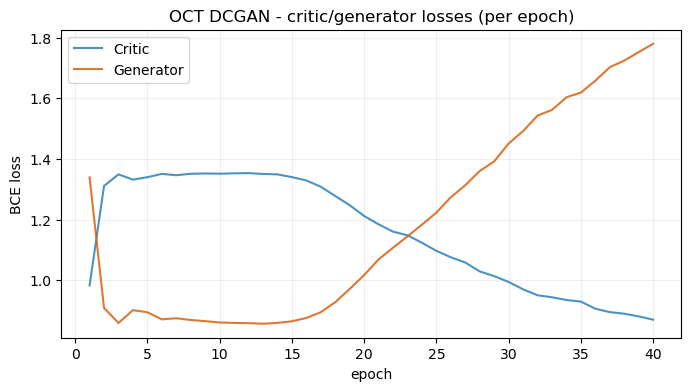

In [15]:
oct_generator, oct_d_losses, oct_g_losses = fit_image_gan(
    oct_generator, oct_critic, oct_images, OCT_EPOCHS, OCT_LATENT, "oct")
plot_loss_history(oct_d_losses, oct_g_losses, "OCT DCGAN - critic/generator losses (per epoch)", None)

## 2.1.4 - How good are the fakes? Side-by-side scans and FID

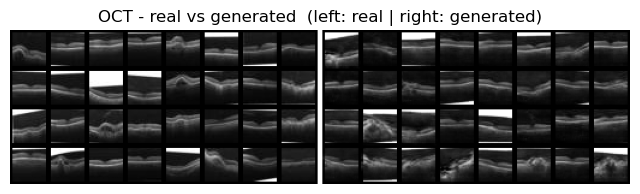

OCT DCGAN: FID = 20.50


In [16]:
frechet = FrechetInception()

oct_fake = oct_generator(tf.random.normal([2000, OCT_LATENT]), training=False).numpy()
show_real_fake(oct_images[:32], oct_fake[:32], "OCT - real vs generated", None)
oct_fid = report_fid(frechet, oct_images, oct_fake, "OCT DCGAN")

## 2.1 extra credit - A class-conditional GAN

For the extension I made the GAN class-aware. The generator concatenates a class embedding onto the latent vector. The critic uses **late-fusion** conditioning: it runs the image through the convolutions on its own and mixes in a small class embedding only at the final dense layer. Feeding the label in as a full extra image channel made the critic far too strong, so this keeps the class cue weak. It trains with instance noise on the images, a slower critic learning rate (two-time-scale), and two generator updates per critic update.

In [17]:
def oct_cgan_generator_net(latent_dim, num_classes, embed_dim=64):
    """Conditional generator: a class embedding is concatenated onto the latent vector,
    then the shared OCT DCGAN trunk (dcgan_generator_body) grows a 4x4 map up to 32x32."""
    noise = keras.Input(shape=(latent_dim,), name="z")
    label = keras.Input(shape=(1,), dtype="int32", name="label")
    label_vec = layers.Flatten()(layers.Embedding(num_classes, embed_dim)(label))
    x = layers.Concatenate()([noise, label_vec])
    image = dcgan_generator_body(x)
    return keras.Model([noise, label], image, name="scan_cgan_generator")

def oct_cgan_critic_net(num_classes, embed_dim=32):
    """Conditional critic with late-fusion conditioning: the image is processed by the
    convolutions on its own, and a small label embedding is mixed in only just before the
    logit. Feeding the label in as a full extra image channel made the critic far too
    strong, so the class cue is kept deliberately weak."""
    image = keras.Input(shape=(32, 32, 1), name="image")
    label = keras.Input(shape=(1,), dtype="int32", name="label")
    x = image
    for i, filters in enumerate((32, 64, 128)):
        x = layers.Conv2D(filters, 4, strides=2, padding="same")(x)
        if i > 0:
            x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    label_vec = layers.Flatten()(layers.Embedding(num_classes, embed_dim)(label))
    merged = layers.Concatenate()([x, label_vec])
    merged = layers.Dropout(0.4)(merged)
    logit = layers.Dense(1)(merged)
    return keras.Model([image, label], logit, name="scan_cgan_critic")


[cgan]   1/40 -> D 1.245 / G 0.988
[cgan]   2/40 -> D 1.256 / G 1.009
[cgan]   3/40 -> D 1.344 / G 1.028
[cgan]   4/40 -> D 1.203 / G 1.102
[cgan]   5/40 -> D 1.141 / G 1.078
[cgan]   6/40 -> D 1.097 / G 0.993
[cgan]   7/40 -> D 1.261 / G 1.124
[cgan]   8/40 -> D 1.140 / G 1.205
[cgan]   9/40 -> D 1.153 / G 1.242
[cgan]  10/40 -> D 1.283 / G 1.260
[cgan]  11/40 -> D 1.277 / G 1.208
[cgan]  12/40 -> D 1.109 / G 1.214
[cgan]  13/40 -> D 1.235 / G 1.201
[cgan]  14/40 -> D 1.226 / G 1.211
[cgan]  15/40 -> D 1.247 / G 1.104
[cgan]  16/40 -> D 1.302 / G 1.213
[cgan]  17/40 -> D 1.170 / G 1.274
[cgan]  18/40 -> D 1.226 / G 1.065
[cgan]  19/40 -> D 1.318 / G 1.157
[cgan]  20/40 -> D 1.106 / G 1.186
[cgan]  21/40 -> D 1.420 / G 1.018
[cgan]  22/40 -> D 1.281 / G 1.247
[cgan]  23/40 -> D 1.221 / G 1.184
[cgan]  24/40 -> D 1.140 / G 1.118
[cgan]  25/40 -> D 1.198 / G 1.186
[cgan]  26/40 -> D 1.125 / G 1.322
[cgan]  27/40 -> D 1.278 / G 1.067
[cgan]  28/40 -> D 1.184 / G 1.247
[cgan]  29/40 -> D 1

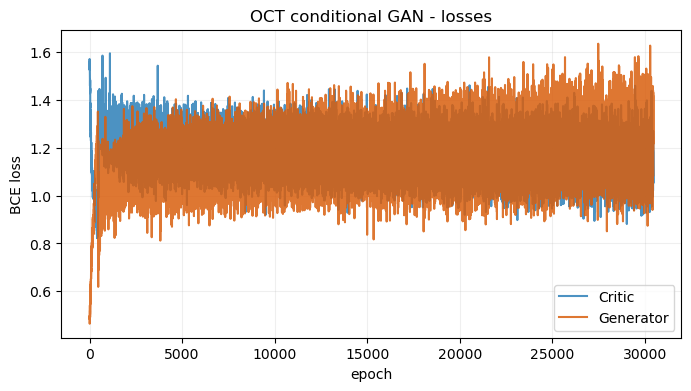

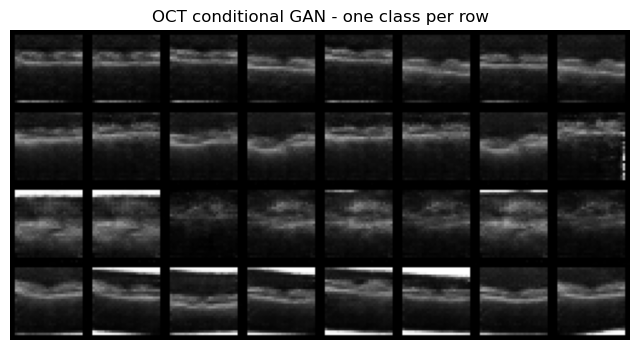

  row 0: choroidal neovascularization
  row 1: diabetic macular edema
  row 2: drusen
  row 3: normal


In [18]:
def fit_oct_cgan(images_signed, labels, epochs, latent_dim, num_classes, batch_size=128):
    """Conditional GAN trainer. To stop the critic dominating it uses instance noise on
    the images, a two-time-scale rule (critic learns slower) and two generator updates
    per critic update."""
    seed_keras()
    generator = oct_cgan_generator_net(latent_dim, num_classes)
    critic = oct_cgan_critic_net(num_classes)
    g_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)
    d_opt = keras.optimizers.Adam(1e-4, beta_1=0.5)

    @tf.function
    def step(real_images, real_labels, noise_std):
        batch = tf.shape(real_images)[0]
        z = tf.random.normal([batch, latent_dim])
        sampled = tf.random.uniform([batch, 1], 0, num_classes, dtype=tf.int32)
        fake_images = generator([z, sampled], training=True)
        real_noisy = real_images + tf.random.normal(tf.shape(real_images)) * noise_std
        fake_noisy = fake_images + tf.random.normal(tf.shape(fake_images)) * noise_std
        with tf.GradientTape() as d_tape:
            real_logits = critic([real_noisy, real_labels], training=True)
            fake_logits = critic([fake_noisy, sampled], training=True)
            d_loss = (LOGIT_BCE(tf.ones_like(real_logits) * 0.9, real_logits)
                      + LOGIT_BCE(tf.zeros_like(fake_logits), fake_logits))
        d_opt.apply_gradients(zip(d_tape.gradient(d_loss, critic.trainable_variables),
                                  critic.trainable_variables))
        g_loss = 0.0
        for _ in range(2):
            z = tf.random.normal([batch, latent_dim])
            sampled = tf.random.uniform([batch, 1], 0, num_classes, dtype=tf.int32)
            with tf.GradientTape() as g_tape:
                gen = generator([z, sampled], training=True)
                gen_noisy = gen + tf.random.normal(tf.shape(gen)) * noise_std
                fake_logits = critic([gen_noisy, sampled], training=True)
                g_loss = LOGIT_BCE(tf.ones_like(fake_logits), fake_logits)
            g_opt.apply_gradients(zip(g_tape.gradient(g_loss, generator.trainable_variables),
                                      generator.trainable_variables))
        return d_loss, g_loss

    dataset = to_dataset(images_signed, batch_size, labels=labels.reshape(-1, 1))
    d_losses, g_losses = [], []
    for epoch in range(1, epochs + 1):
        noise_std = tf.constant(0.1 * max(0.0, 1.0 - epoch / epochs), tf.float32)
        for real_batch, label_batch in dataset:
            d_loss, g_loss = step(real_batch, label_batch, noise_std)
            d_losses.append(float(d_loss)); g_losses.append(float(g_loss))
        print(f"[cgan] {epoch:>3}/{epochs} -> D {float(d_loss):.3f} / G {float(g_loss):.3f}")
    return generator, d_losses, g_losses


oct_cgan_generator, oct_cgan_d, oct_cgan_g = fit_oct_cgan(
    oct_images, oct_labels, OCT_EPOCHS, OCT_LATENT, OCT_NUM_CLASSES)
plot_loss_history(oct_cgan_d, oct_cgan_g, "OCT conditional GAN - losses", None)

_class_rows = []
for _cls in range(OCT_NUM_CLASSES):
    _z = tf.random.normal([8, OCT_LATENT])
    _lbl = tf.fill([8, 1], _cls)
    _class_rows.append(oct_cgan_generator([_z, _lbl], training=False).numpy())
show_samples(np.concatenate(_class_rows, axis=0), "OCT conditional GAN - one class per row",
             None, cols=8)
for _cls in range(OCT_NUM_CLASSES):
    print(f"  row {_cls}: {OCT_CLASS_NAMES[str(_cls)]}")

## 2.1 - Notes and reflection

**Realism.** The generated scans capture the main structure: a bright, curved retinal band over a darker background, and the batch varies in the shape and position of that band rather than reprinting one image. The FID comes out at 20.50, the lowest (best) of the three image models in this notebook, which fits the samples landing fairly close to the real scans.

**The conditional model.** The per-class samples look different from one row to the next, so the class embedding is genuinely being used rather than ignored. The classes that appear most often in the training set come out looking the most convincing, which is what I would expect given how imbalanced OCTMNIST is.

**Keeping the conditional model stable.** My first attempt at the conditional GAN was the odd one out: the critic overpowered the generator, its loss flat-lined at a very low value while the generator loss ran away. The cause was how the label reached the critic - fed in as a full 32x32 image channel, it was such a strong cue that the critic could tell real from fake almost perfectly. The fix was late-fusion conditioning (the small label embedding is only mixed in at the final dense layer), plus instance noise on the images, a slower critic learning rate, and two generator steps per critic step. With those changes the two losses trade off in a healthy range instead of one side running away - over the 40 epochs the critic stays around 1.05-1.42 and the generator around 0.97-1.42, both holding in a healthy band rather than one side running away - and the per-class rows stay distinct.

**Where it falls short.** The obvious remaining gap is fine texture. The generated scans are a bit too smooth and miss some of the speckle and sub-layer detail the real ones have, even though the overall band shape is captured well.

**On GANs "hallucinating" (the duck point).** The nickname comes from the duck test: if it looks like a duck and quacks like a duck, call it a duck. Even a low-FID GAN like this one is only trained to pass that surface-level test. The critic has no idea what is anatomically correct, so a confident, realistic-looking structure can still correspond to nothing in any real image. For a retinal scan that could mean inventing a bright patch that resembles pathology when none was there, or smoothing away a genuine feature. That is exactly why synthetic scans like these belong in data augmentation or teaching, not in actual diagnosis, no matter how good the FID looks. A low FID says the overall statistics match, not that any single image can be trusted.

# Part 2.2 - Fabricating network traffic from CICIDS 2017 (PyTorch)

CICIDS 2017 records each network flow as ~78 numeric features rather than an image, so this GAN is a fully-connected network rather than a convolutional one. I implemented this part in **PyTorch** (the same framework as Part 1), with a compact hand-written training loop and a noise dimension of 56 - a deliberately different toolchain from the image parts, which keeps the tabular work self-contained.

The workflow follows the brief: gather and merge the per-day CSVs, look at the class balance, then focus on the Wednesday file, train a GAN on those feature vectors, and line the real and synthetic data up with PCA, t-SNE and simple moment-gap metrics. The extension retrains on every day.

> **Data setup.** The eight CICIDS 2017 CSVs are found automatically - first in the notebook's own folder, otherwise downloaded from Kaggle - so nothing needs editing by hand.
>
> **A note on the labels.** The brief says "DDoS", but the Wednesday attacks are actually single-source DoS (Hulk, GoldenEye, slowloris, Slowhttptest); the real DDoS flows are in the Friday file. I model Wednesday as BENIGN vs DoS as named, but flag the mismatch here.

In [19]:
NOISE_DIM = 56
print(f"CICIDS traffic-GAN noise dimension = {NOISE_DIM}")

CICIDS traffic-GAN noise dimension = 56


## 2.2.1 - Locating the capture files

In [20]:
import os
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# The eight CICIDS 2017 day-files (fixed dataset names).
CICIDS_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]


def _gather(root):
    """Return the paths of all eight day-files found anywhere under root, else None."""
    if not root or not os.path.isdir(root):
        return None
    seen = {}
    for base, _dirs, names in os.walk(root):
        for fn in names:
            if fn in CICIDS_FILES and fn not in seen:
                seen[fn] = os.path.join(base, fn)
    return [seen[fn] for fn in CICIDS_FILES] if len(seen) == len(CICIDS_FILES) else None


csv_paths = _gather(os.getcwd())
if csv_paths is not None:
    print("Loading the CICIDS 2017 CSVs from the local directory.")
else:
    import kagglehub
    csv_paths = _gather(kagglehub.dataset_download("chethuhn/network-intrusion-dataset"))
    if csv_paths is None:
        raise FileNotFoundError("CICIDS 2017 CSV files not found locally or on Kaggle.")
    print("Loading the CICIDS 2017 CSVs from the Kaggle download.")
print(f"Located all {len(csv_paths)} day-files.")

Loading the CICIDS 2017 CSVs from the Kaggle download.
Located all 8 day-files.


## 2.2.2 - Merging the daily captures and a first exploration

All eight files get concatenated into one frame, with each row tagged by the day it came from (a `Day` column). Then I look at the overall class balance, how many `Inf`/`NaN` cells need cleaning, and the fraction of attack traffic per day. CICIDS is very imbalanced (BENIGN swamps everything), so the class counts are plotted on a log scale, and the numeric columns are cast to float32 to keep the memory down.

In [21]:
WEEKDAYS = ("monday", "tuesday", "wednesday", "thursday", "friday")


def _weekday(path):
    low = os.path.basename(path).lower()
    return next((d.capitalize() for d in WEEKDAYS if d in low), "Unknown")


tables = []
for path in csv_paths:
    tbl = pd.read_csv(path, low_memory=False)
    tbl.columns = tbl.columns.str.strip()
    tbl = tbl.loc[:, ~tbl.columns.str.startswith("Unnamed")]
    if "Label" not in tbl.columns:
        continue
    numeric = tbl.select_dtypes(include=[np.number]).columns
    tbl[numeric] = tbl[numeric].astype(np.float32)
    tbl["Label"] = tbl["Label"].astype(str).str.strip()
    tbl["Day"] = _weekday(path)
    tables.append(tbl)

# join="inner" keeps only the columns every file shares, avoiding all-NaN phantom columns.
flows = pd.concat(tables, ignore_index=True, join="inner")
del tables
print(f"Merged {flows.shape[0]:,} flows across {flows.shape[1]} columns")

Merged 2,830,743 flows across 80 columns


Class counts (all days):
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


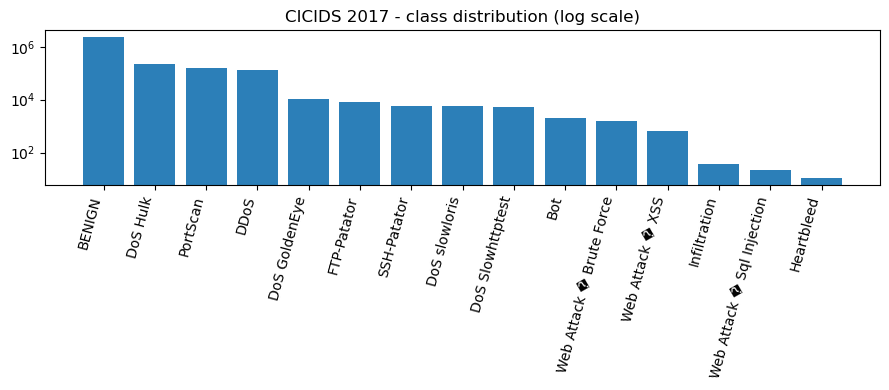

In [22]:
label_counts = flows["Label"].value_counts()
print("Class counts (all days):")
print(label_counts)

plt.figure(figsize=(9, 4))
plt.bar(range(len(label_counts)), label_counts.values, color="#2c7fb8")
plt.yscale("log")
plt.xticks(range(len(label_counts)), label_counts.index, rotation=75, ha="right")
plt.title("CICIDS 2017 - class distribution (log scale)")
plt.tight_layout()
plt.show()

In [23]:
feature_cols = [c for c in flows.columns
                if c not in ("Label", "Day") and np.issubdtype(flows[c].dtype, np.number)]
print("Numeric features:", len(feature_cols))

feature_block = flows[feature_cols].to_numpy()
print(f"Inf cells: {int(np.isinf(feature_block).sum()):,} | NaN cells: {int(np.isnan(feature_block).sum()):,}")

attack_by_day = (flows.assign(is_attack=(flows["Label"] != "BENIGN").astype(int))
                      .groupby("Day")["is_attack"].mean())
print("Daily attack fraction:")
print(attack_by_day)

Numeric features: 78
Inf cells: 4,376 | NaN cells: 1,358
Daily attack fraction:
Day
Friday       0.410843
Monday       0.000000
Thursday     0.004828
Tuesday      0.031027
Wednesday    0.364762
Name: is_attack, dtype: float64


## 2.2.3 - Wednesday only (BENIGN vs DoS) and feature scaling

The GAN itself only trains on the Wednesday rows (`Day == "Wednesday"`). I drop the `Inf`/`NaN` rows first, build a binary BENIGN-vs-DoS target, and keep the numeric features. Because CICIDS has some wild outliers, I scale the features with a RobustScaler (median and IQR, so no Gaussian assumption) and then clip to +/-5 - without that clipping the extreme values tend to destabilise training.

In [24]:
from sklearn.preprocessing import RobustScaler

wednesday = flows[flows["Day"] == "Wednesday"].replace([np.inf, -np.inf], np.nan).dropna()
if wednesday.empty:
    raise ValueError("No Wednesday rows found - check the CSV file names.")
print("Wednesday - class distribution:")
print(wednesday["Label"].value_counts())

wed_target = (wednesday["Label"] != "BENIGN").astype(int).to_numpy()
wed_raw = wednesday[feature_cols].to_numpy().astype(np.float32)

# RobustScaler (median/IQR) then clip to +/-5 - CICIDS has heavy outliers that
# otherwise destabilise training.
scaler = RobustScaler().fit(wed_raw)


def scale_block(matrix):
    return np.clip(scaler.transform(matrix), -5.0, 5.0).astype(np.float32)


wed_features = scale_block(wed_raw)
print(f"Wednesday feature matrix: {wed_features.shape}")

Wednesday - class distribution:
Label
BENIGN              439683
DoS Hulk            230124
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64
Wednesday feature matrix: (691406, 78)


In [25]:
set_all_seeds()
ROW_CAP = 20000
keep = np.random.permutation(wed_features.shape[0])[:ROW_CAP]
train_features = wed_features[keep]
FEATURE_DIM = train_features.shape[1]
print(f"Training the traffic GAN on {train_features.shape[0]} flows x {FEATURE_DIM} features")

Training the traffic GAN on 20000 flows x 78 features


## 2.2.4 - A dense feature-vector GAN in PyTorch

The generator maps a noise vector to a full feature vector with a linear output layer (the scaled features are unbounded). The critic is a small dense network returning one logit. Training is a plain PyTorch loop - one critic step then one generator step per batch - with the non-saturating loss and one-sided label smoothing (real target 0.9).

In [26]:
class FlowGenerator(nn.Module):
    """Dense generator 96 -> 192 -> 96 (BatchNorm + LeakyReLU) -> feature vector."""

    def __init__(self, noise_dim, feature_dim):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(noise_dim, 96), nn.BatchNorm1d(96), nn.LeakyReLU(0.2),
            nn.Linear(96, 192), nn.BatchNorm1d(192), nn.LeakyReLU(0.2),
            nn.Linear(192, 96), nn.BatchNorm1d(96), nn.LeakyReLU(0.2),
            nn.Linear(96, feature_dim),
        )

    def forward(self, z):
        return self.body(z)


class FlowCritic(nn.Module):
    """Dense critic with two width-128 hidden layers -> single logit."""

    def __init__(self, feature_dim):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(feature_dim, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.body(x)

In [27]:
from torch.utils.data import DataLoader, TensorDataset


def train_flow_gan(matrix, epochs, noise_dim, batch=256, lr=2e-4):
    """Train the tabular GAN in PyTorch; returns (generator, critic_hist, gen_hist)
    with per-epoch mean losses."""
    set_all_seeds()
    feature_dim = matrix.shape[1]
    generator = FlowGenerator(noise_dim, feature_dim).to(DEVICE)
    critic = FlowCritic(feature_dim).to(DEVICE)
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_c = torch.optim.Adam(critic.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()

    # drop_last keeps every batch > 1 so the generator's BatchNorm stays valid.
    loader = DataLoader(TensorDataset(torch.tensor(matrix, dtype=torch.float32)),
                        batch_size=batch, shuffle=True, drop_last=True)

    critic_hist, gen_hist = [], []
    for epoch in range(1, epochs + 1):
        c_run, g_run = [], []
        for (real,) in loader:
            real = real.to(DEVICE)
            n = real.size(0)
            fake = generator(torch.randn(n, noise_dim, device=DEVICE)).detach()
            c_loss = (bce(critic(real), torch.full((n, 1), 0.9, device=DEVICE))
                      + bce(critic(fake), torch.zeros(n, 1, device=DEVICE)))
            opt_c.zero_grad(set_to_none=True); c_loss.backward(); opt_c.step()

            g_loss = bce(critic(generator(torch.randn(n, noise_dim, device=DEVICE))),
                         torch.ones(n, 1, device=DEVICE))
            opt_g.zero_grad(set_to_none=True); g_loss.backward(); opt_g.step()
            c_run.append(float(c_loss)); g_run.append(float(g_loss))
        critic_hist.append(sum(c_run) / len(c_run)); gen_hist.append(sum(g_run) / len(g_run))
        if epoch == 1 or epoch % 10 == 0:
            print(f"epoch {epoch:>3}/{epochs} | critic={critic_hist[-1]:.4f} | gen={gen_hist[-1]:.4f}")
    return generator, critic_hist, gen_hist

epoch   1/60 | critic=1.2449 | gen=0.6844
epoch  10/60 | critic=1.0658 | gen=1.2892
epoch  20/60 | critic=1.0471 | gen=1.3069
epoch  30/60 | critic=1.0545 | gen=1.2729
epoch  40/60 | critic=0.9983 | gen=1.3588
epoch  50/60 | critic=0.9538 | gen=1.4407
epoch  60/60 | critic=0.9541 | gen=1.5031


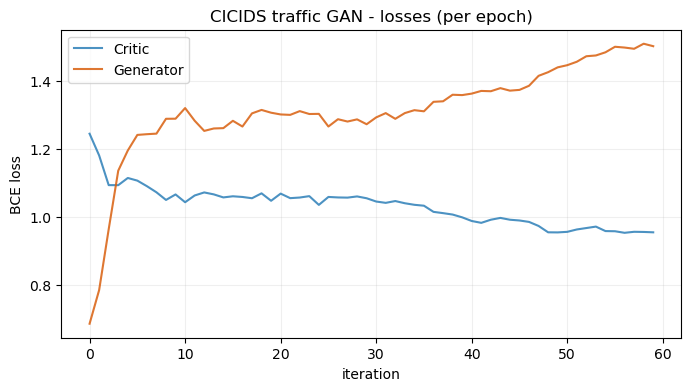

In [28]:
CICIDS_EPOCHS = 60
flow_generator, flow_c_hist, flow_g_hist = train_flow_gan(train_features, CICIDS_EPOCHS, NOISE_DIM)
plot_curves(flow_c_hist, flow_g_hist, "CICIDS traffic GAN - losses (per epoch)", None)

## 2.2.5 - Real vs synthetic: PCA, t-SNE and alignment gaps

To see how close the synthetic data is, I project both real and generated vectors down to 2D. PCA gives a quick linear view (real BENIGN, real DoS and synthetic coloured separately), and t-SNE gives a non-linear view that shows the local structure better. On top of the plots I compute two alignment gaps: the mean absolute difference in per-feature means and in per-feature standard deviations, which put a number on how well the marginals line up.

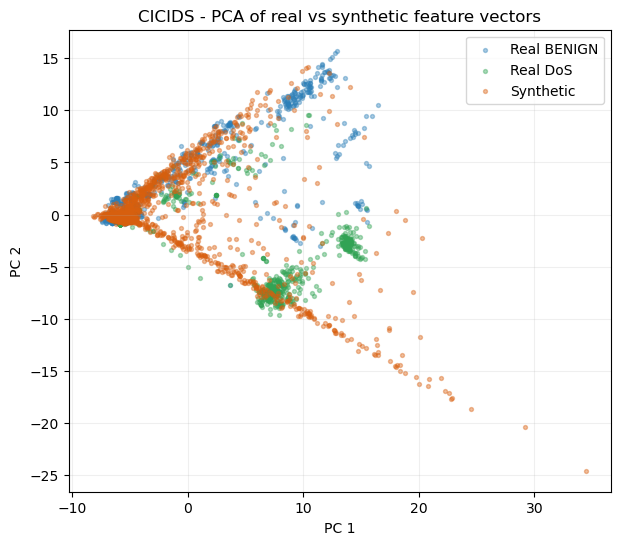

In [29]:
@torch.no_grad()
def synth_flows(generator, count):
    generator.eval()
    out = generator(torch.randn(count, NOISE_DIM, device=DEVICE)).cpu().numpy()
    generator.train()
    return out


EVAL_N = 2000
real_pick = np.random.permutation(wed_features.shape[0])[:EVAL_N]
real_flows = wed_features[real_pick]
real_labels = wed_target[real_pick]
synth = synth_flows(flow_generator, EVAL_N)

projector = PCA(n_components=2).fit(real_flows)
real_xy = projector.transform(real_flows)
synth_xy = projector.transform(synth)

plt.figure(figsize=(7, 6))
plt.scatter(real_xy[real_labels == 0, 0], real_xy[real_labels == 0, 1], s=8, alpha=0.4, label="Real BENIGN", color="#2c7fb8")
plt.scatter(real_xy[real_labels == 1, 0], real_xy[real_labels == 1, 1], s=8, alpha=0.4, label="Real DoS", color="#31a354")
plt.scatter(synth_xy[:, 0], synth_xy[:, 1], s=8, alpha=0.4, label="Synthetic", color="#d95f0e")
plt.title("CICIDS - PCA of real vs synthetic feature vectors")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend(); plt.grid(alpha=0.2)
plt.show()

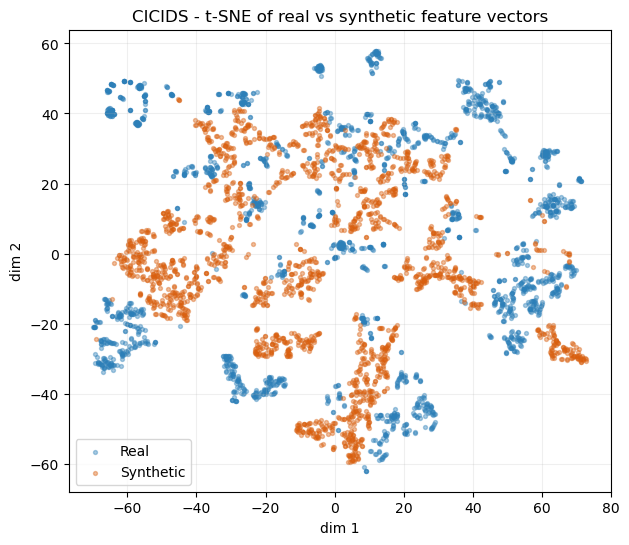

In [30]:
embedded = TSNE(n_components=2, perplexity=30, init="pca", random_state=SEED).fit_transform(
    np.vstack([real_flows, synth]))
plt.figure(figsize=(7, 6))
plt.scatter(embedded[:EVAL_N, 0], embedded[:EVAL_N, 1], s=8, alpha=0.4, label="Real", color="#2c7fb8")
plt.scatter(embedded[EVAL_N:, 0], embedded[EVAL_N:, 1], s=8, alpha=0.4, label="Synthetic", color="#d95f0e")
plt.title("CICIDS - t-SNE of real vs synthetic feature vectors")
plt.xlabel("dim 1"); plt.ylabel("dim 2"); plt.legend(); plt.grid(alpha=0.2)
plt.show()

CICIDS alignment | mean |dmu| = 0.2435 | mean |dsigma| = 0.2395


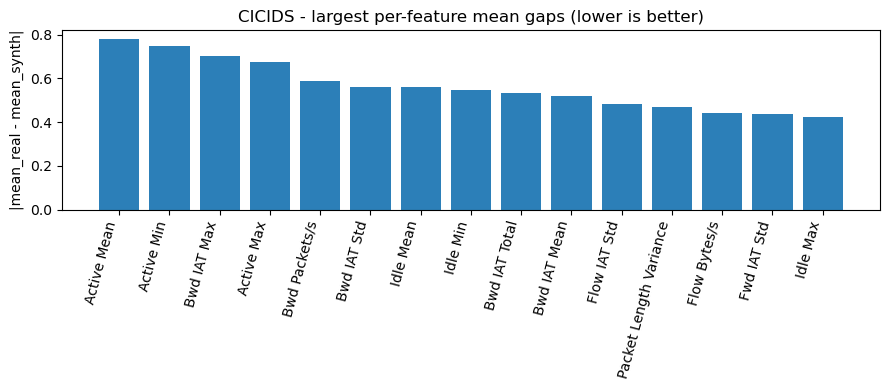

In [31]:
def moment_gaps(real, fake):
    """Mean absolute per-feature mean and std differences (lower = better aligned)."""
    return np.abs(real.mean(0) - fake.mean(0)), np.abs(real.std(0) - fake.std(0))


mean_gap, std_gap = moment_gaps(real_flows, synth)
print(f"CICIDS alignment | mean |dmu| = {mean_gap.mean():.4f} | mean |dsigma| = {std_gap.mean():.4f}")

worst = np.argsort(mean_gap)[::-1][:15]
plt.figure(figsize=(9, 4))
plt.bar(range(len(worst)), mean_gap[worst], color="#2c7fb8")
plt.xticks(range(len(worst)), [feature_cols[i] for i in worst], rotation=75, ha="right")
plt.title("CICIDS - largest per-feature mean gaps (lower is better)")
plt.ylabel("|mean_real - mean_synth|"); plt.tight_layout()
plt.show()

## 2.2 extra credit - Scaling up to every day and generalisation

For the extra credit I retrain the same dense GAN on the entire CICIDS 2017 dataset, all days and every attack type, to see whether one unconditional generator can spread across the many attack families or just collapses onto the dominant BENIGN mode. In the PCA plot the real points are coloured by attack family so it is easier to see where the synthetic points land.

In [32]:
def family_of(label):
    """Collapse fine-grained CICIDS labels into coarse families for colouring."""
    if label == "BENIGN":
        return "BENIGN"
    if label.startswith("DoS"):
        return "DoS"
    if label in ("DDoS", "PortScan", "Bot", "Infiltration", "Heartbleed"):
        return label
    if label.startswith("Web Attack"):
        return "Web Attack"
    if label.startswith(("FTP", "SSH")):
        return "Brute Force"
    return "Other"


set_all_seeds()
clean = flows.replace([np.inf, -np.inf], np.nan).dropna()
all_families = clean["Label"].map(family_of).to_numpy()
all_features = scale_block(clean[feature_cols].to_numpy().astype(np.float32))   # reuse the Wednesday scaler
del clean

pick_all = np.random.permutation(all_features.shape[0])[:30000]
train_all = all_features[pick_all]
print(f"Full-dataset GAN training on {train_all.shape[0]} flows sampled from every day")

Full-dataset GAN training on 30000 flows sampled from every day


epoch   1/60 | critic=1.2375 | gen=0.7001
epoch  10/60 | critic=1.1347 | gen=1.1130
epoch  20/60 | critic=1.0408 | gen=1.2751
epoch  30/60 | critic=0.9728 | gen=1.4294
epoch  40/60 | critic=0.9272 | gen=1.5498
epoch  50/60 | critic=0.9055 | gen=1.5864
epoch  60/60 | critic=0.8669 | gen=1.7157


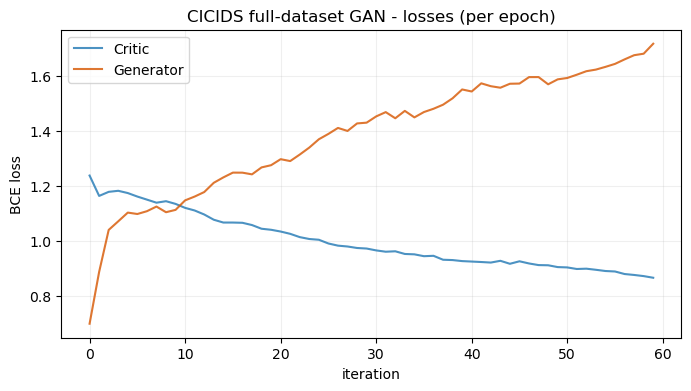

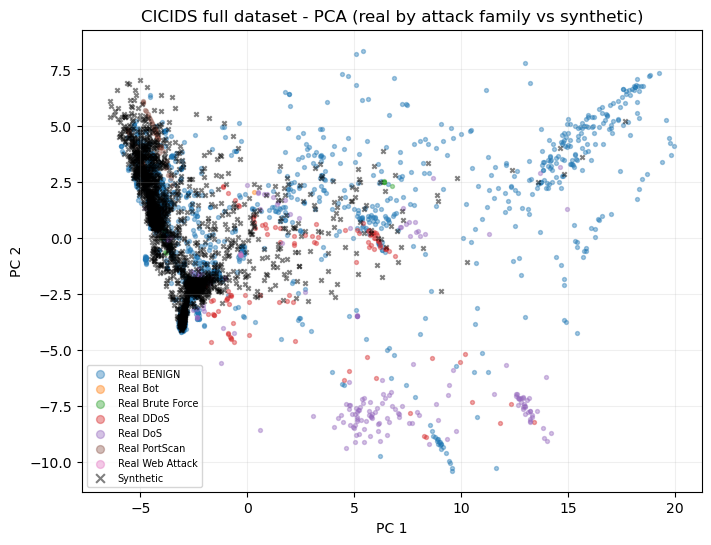

Full-dataset alignment | mean |dmu| = 0.2955 (Wednesday 0.2435)
Full-dataset alignment | mean |dsigma| = 0.5277 (Wednesday 0.2395)


In [33]:
all_generator, all_c_hist, all_g_hist = train_flow_gan(train_all, CICIDS_EPOCHS, NOISE_DIM)
plot_curves(all_c_hist, all_g_hist, "CICIDS full-dataset GAN - losses (per epoch)", None)

FULL_N = 2500
full_pick = np.random.permutation(all_features.shape[0])[:FULL_N]
full_real = all_features[full_pick]
full_families = all_families[full_pick]
full_synth = synth_flows(all_generator, FULL_N)

full_projector = PCA(n_components=2).fit(full_real)
full_real_xy = full_projector.transform(full_real)
full_synth_xy = full_projector.transform(full_synth)

plt.figure(figsize=(8, 6))
for fam in sorted(set(full_families)):
    mask = full_families == fam
    plt.scatter(full_real_xy[mask, 0], full_real_xy[mask, 1], s=8, alpha=0.4, label=f"Real {fam}")
plt.scatter(full_synth_xy[:, 0], full_synth_xy[:, 1], s=10, alpha=0.5, marker="x", color="black", label="Synthetic")
plt.title("CICIDS full dataset - PCA (real by attack family vs synthetic)")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend(fontsize=7, markerscale=2); plt.grid(alpha=0.2)
plt.show()

full_mean_gap, full_std_gap = moment_gaps(full_real, full_synth)
print(f"Full-dataset alignment | mean |dmu| = {full_mean_gap.mean():.4f} (Wednesday {mean_gap.mean():.4f})")
print(f"Full-dataset alignment | mean |dsigma| = {full_std_gap.mean():.4f} (Wednesday {std_gap.mean():.4f})")

## 2.2 - Notes and reflection

**How well it lines up.** In both the PCA and t-SNE plots the generated points sit inside the main cluster of real data rather than off on their own, though the synthetic cloud is a bit more tightly packed than the real one. The alignment gaps put numbers on this: a mean absolute mean-gap of 0.2435 and a mean std-gap of 0.2395 on the Wednesday data. That is a moderate gap - the generator finds the rough location and scale of the real distribution but does not reproduce it exactly, especially for the more skewed, heavy-tailed features.

**The full dataset.** Retraining on all eight days gives a mean-gap of 0.2955 and a std-gap of 0.5277 (versus 0.2435 and 0.2395 for Wednesday only). So folding in every attack type makes the fit a bit looser, and mostly on the spread - the std-gap roughly doubles. My reading is that BENIGN and the high-volume attacks dominate even with all days combined, so the generator tracks the main modes while the rare classes (Heartbleed, Infiltration, and so on) stay under-represented because there are so few of those rows.

**The label note again.** As mentioned above, the core Wednesday task is really DoS, not DDoS. True DDoS only appears once the Friday file is folded into the all-days extension, which is what the code does.

**"Ducks."** The duck-test idea carries over directly. A generated flow only has to convince the critic that it "looks statistically like real traffic", not that it reflects how a real attack actually works. A flow that looks plausible but matches no genuine attack or benign behaviour would be a real problem if you used it to augment intrusion-detection training data: it could teach a downstream model to expect attacks that do not look like the real thing, or to treat normal traffic as suspicious. And unlike an image, you cannot glance at a row of numbers and tell it is wrong, which is why the alignment gaps above (especially the std-gap, where this kind of subtle mismatch shows up first) are the main check I have.

# Part 2.3 - Doodling with GANs: QuickDraw sketches (Keras DCGAN)

For the last part I train a DCGAN on QuickDraw sketches, reusing the same `GanTrainer` class again. This generator is built the other way round from the OCT one - it uses transposed convolutions (Conv2DTranspose) instead of upsample-then-convolve - just to show a second common way of building a DCGAN generator, and its critic uses dropout instead of BatchNorm. The latent dimension is 64. I track the losses, snapshot samples at a few epochs to watch it improve, and score the generator with FID. The extension runs the same model on a couple of other categories and checks whether FID lines up with a simple "how busy is the sketch" measure.

*(This section reuses `to_dataset`, `LOGIT_BCE`, the `GanTrainer` class and the FID scorer from earlier in Part 2.)*

In [34]:
SKETCH_LATENT = 64
SKETCH_EXTRA_CATEGORIES = ["cat", "house"]
SKETCH_EPOCHS = 30
print(f"QuickDraw sketch GAN: latent={SKETCH_LATENT} | extra categories={SKETCH_EXTRA_CATEGORIES}")

QuickDraw sketch GAN: latent=64 | extra categories=['cat', 'house']


## 2.3.1 - Fetching and previewing 'birthday cake' doodles

downloading QuickDraw category: birthday cake
birthday cake bitmaps: (144982, 28, 28)


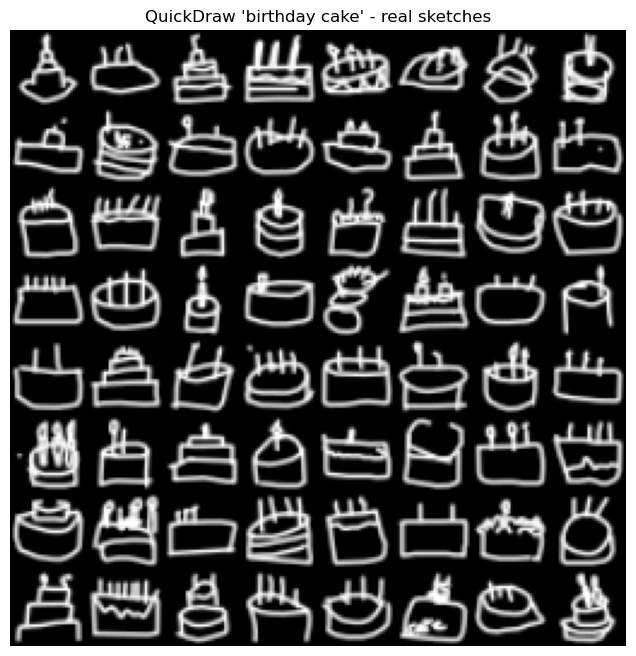

In [35]:
import urllib.request

QUICKDRAW_DIR = os.path.join(RESULTS_DIR, "quickdraw")
os.makedirs(QUICKDRAW_DIR, exist_ok=True)


def fetch_quickdraw(category):
    """Download a QuickDraw numpy-bitmap category -> (N, 28, 28) uint8 array."""
    url = ("https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"
           + category.replace(" ", "%20") + ".npy")
    local = os.path.join(QUICKDRAW_DIR, category.replace(" ", "_") + ".npy")
    if not os.path.exists(local):
        print("downloading QuickDraw category:", category)
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req) as resp, open(local, "wb") as fh:
            fh.write(resp.read())
    return np.load(local).reshape(-1, 28, 28)


def bitmaps_to_signed(uint8_images, size=32):
    """(N, 28, 28) uint8 -> (N, size, size, 1) float32 in [-1, 1]."""
    scaled = uint8_images.astype("float32")[..., None] / 127.5 - 1.0
    return tf.image.resize(scaled, (size, size)).numpy()


def ink_fraction(uint8_images, sample=3000):
    """Mean normalised ink coverage - a rough sketch-complexity proxy."""
    idx = np.random.permutation(len(uint8_images))[:sample]
    return float((uint8_images[idx].astype(np.float32) / 255.0).mean())


cake_uint8 = fetch_quickdraw("birthday cake")
cake_images = bitmaps_to_signed(cake_uint8)
print("birthday cake bitmaps:", cake_uint8.shape)
show_samples(cake_images[:64], "QuickDraw 'birthday cake' - real sketches", None)

## 2.3.2 - The doodle DCGAN architecture

`sketch_generator_net` and `sketch_critic_net` return the Functional DCGAN networks (transposed-conv generator, strided-conv critic with dropout), and `fit_sketch_gan` trains them through the shared `GanTrainer` with a snapshot callback that grabs a grid of generated samples at a few epochs so I can show how the outputs develop.

In [36]:
def sketch_generator_net(latent_dim):
    """DCGAN generator from Conv2DTranspose blocks: (latent,) -> (32, 32, 1) in [-1, 1]."""
    noise = keras.Input(shape=(latent_dim,))
    x = layers.Dense(4 * 4 * 256, use_bias=False)(noise)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((4, 4, 256))(x)
    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(x)   # 4 -> 8
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False)(x)     # 8 -> 16
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    image = layers.Conv2DTranspose(1, 4, strides=2, padding="same",
                                   use_bias=False, activation="tanh")(x)                # 16 -> 32
    return keras.Model(noise, image, name="sketch_generator")


def sketch_critic_net():
    """DCGAN critic from strided convolutions + dropout: (32, 32, 1) -> logit."""
    image = keras.Input(shape=(32, 32, 1))
    x = layers.Conv2D(64, 4, strides=2, padding="same")(image)          # 32 -> 16
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(128, 4, strides=2, padding="same")(x)             # 16 -> 8
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(256, 4, strides=2, padding="same")(x)            # 8 -> 4
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Flatten()(x)
    logit = layers.Dense(1)(x)
    return keras.Model(image, logit, name="sketch_critic")

In [37]:
def fit_sketch_gan(images_signed, epochs, tag, batch_size=128):
    """Train a sketch DCGAN by reusing the shared image-GAN trainer."""
    generator = sketch_generator_net(SKETCH_LATENT)
    critic = sketch_critic_net()
    return fit_image_gan(generator, critic, images_signed, epochs, SKETCH_LATENT, f"qd_{tag}", batch_size)


def sample_sketch(generator, count):
    return generator(tf.random.normal([count, SKETCH_LATENT]), training=False).numpy()

## 2.3.3 - Training on cakes and scoring with FID

Epoch 1/30


I0000 00:00:1785756864.300553  680009 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_281416__.46


1132/1132 - 21s - 19ms/step - d_loss: 1.1161 - g_loss: 1.3539
Epoch 2/30
1132/1132 - 8s - 7ms/step - d_loss: 1.1276 - g_loss: 1.2615
Epoch 3/30
1132/1132 - 8s - 7ms/step - d_loss: 1.1049 - g_loss: 1.3282
Epoch 4/30
1132/1132 - 8s - 7ms/step - d_loss: 1.0678 - g_loss: 1.4187
Epoch 5/30
1132/1132 - 8s - 7ms/step - d_loss: 0.9997 - g_loss: 1.5753
Epoch 6/30
1132/1132 - 8s - 7ms/step - d_loss: 0.8909 - g_loss: 1.8771
Epoch 7/30
1132/1132 - 8s - 7ms/step - d_loss: 0.7951 - g_loss: 2.2158
Epoch 8/30
1132/1132 - 8s - 7ms/step - d_loss: 0.7353 - g_loss: 2.4895
Epoch 9/30
1132/1132 - 8s - 7ms/step - d_loss: 0.6958 - g_loss: 2.7032
Epoch 10/30
1132/1132 - 8s - 7ms/step - d_loss: 0.6632 - g_loss: 2.8934
Epoch 11/30
1132/1132 - 8s - 7ms/step - d_loss: 0.6440 - g_loss: 3.0286
Epoch 12/30
1132/1132 - 8s - 7ms/step - d_loss: 0.6467 - g_loss: 3.0847
Epoch 13/30
1132/1132 - 8s - 7ms/step - d_loss: 0.6108 - g_loss: 3.2573
Epoch 14/30
1132/1132 - 8s - 7ms/step - d_loss: 0.6009 - g_loss: 3.3399
Epoch 15/3

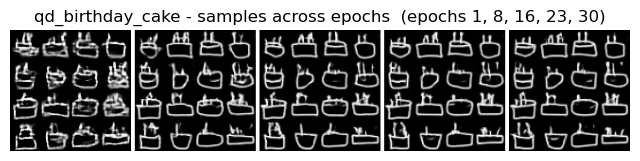

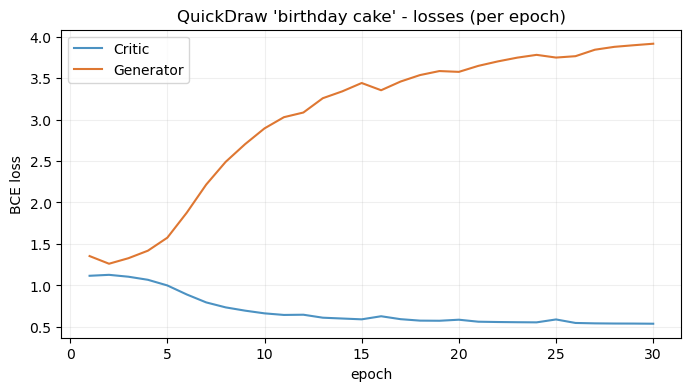

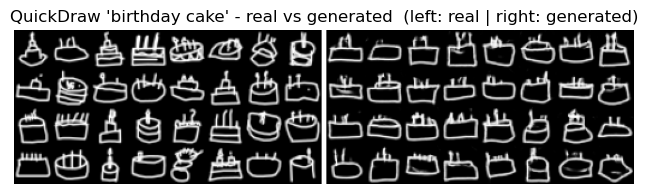

QuickDraw birthday cake: FID = 24.51


In [38]:
cake_generator, cake_d_losses, cake_g_losses = fit_sketch_gan(cake_images, SKETCH_EPOCHS, "birthday_cake")
plot_loss_history(cake_d_losses, cake_g_losses, "QuickDraw 'birthday cake' - losses (per epoch)", None)

cake_fake = sample_sketch(cake_generator, 2000)
show_real_fake(cake_images[:32], cake_fake[:32], "QuickDraw 'birthday cake' - real vs generated", None)
cake_fid = report_fid(frechet, cake_images, cake_fake, "QuickDraw birthday cake")

## 2.3 extra credit - More categories and sketch complexity

Here I train the same subclassed DCGAN on a few more QuickDraw categories. I then compare the FID against an ink-density measure (roughly how much of the image is actually drawn on). The intuition is that busier, denser sketches should be harder to model, so I would expect higher ink density to line up with higher FID.

Epoch 1/30


I0000 00:00:1785757655.000216  680012 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_691906__.46


962/962 - 17s - 18ms/step - d_loss: 1.1571 - g_loss: 1.3643
Epoch 2/30
962/962 - 7s - 7ms/step - d_loss: 1.1314 - g_loss: 1.2875
Epoch 3/30
962/962 - 7s - 7ms/step - d_loss: 1.1537 - g_loss: 1.2194
Epoch 4/30
962/962 - 7s - 7ms/step - d_loss: 1.1261 - g_loss: 1.2878
Epoch 5/30
962/962 - 7s - 7ms/step - d_loss: 1.0833 - g_loss: 1.3854
Epoch 6/30
962/962 - 7s - 7ms/step - d_loss: 1.0335 - g_loss: 1.5090
Epoch 7/30
962/962 - 7s - 7ms/step - d_loss: 0.9401 - g_loss: 1.7505
Epoch 8/30
962/962 - 7s - 7ms/step - d_loss: 0.8082 - g_loss: 2.1500
Epoch 9/30
962/962 - 7s - 7ms/step - d_loss: 0.7190 - g_loss: 2.5142
Epoch 10/30
962/962 - 7s - 7ms/step - d_loss: 0.6563 - g_loss: 2.8426
Epoch 11/30
962/962 - 7s - 7ms/step - d_loss: 0.6118 - g_loss: 3.1102
Epoch 12/30
962/962 - 7s - 7ms/step - d_loss: 0.5935 - g_loss: 3.2966
Epoch 13/30
962/962 - 7s - 7ms/step - d_loss: 0.5560 - g_loss: 3.5401
Epoch 14/30
962/962 - 7s - 7ms/step - d_loss: 0.5341 - g_loss: 3.7283
Epoch 15/30
962/962 - 7s - 7ms/step - 

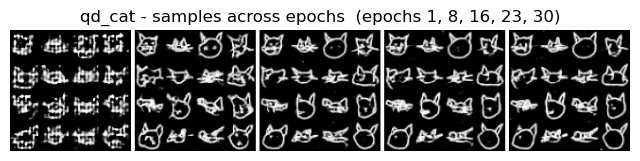

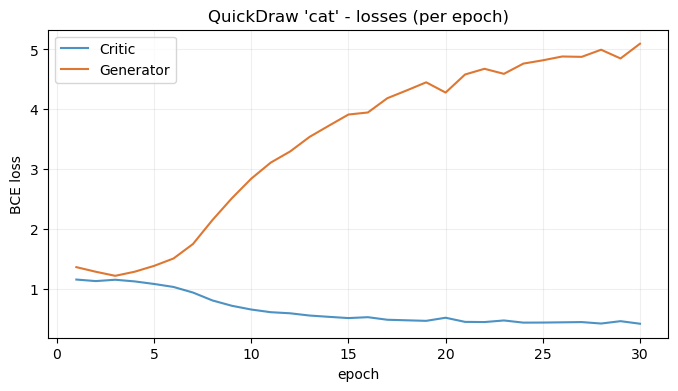

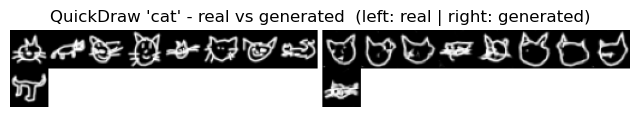

QuickDraw cat: FID = 30.52
Epoch 1/30


I0000 00:00:1785757888.584195  680009 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_818136__.46


1057/1057 - 18s - 17ms/step - d_loss: 1.1634 - g_loss: 1.1731
Epoch 2/30
1057/1057 - 7s - 7ms/step - d_loss: 1.1606 - g_loss: 1.1657
Epoch 3/30
1057/1057 - 7s - 7ms/step - d_loss: 1.1580 - g_loss: 1.1959
Epoch 4/30
1057/1057 - 7s - 7ms/step - d_loss: 1.1234 - g_loss: 1.2552
Epoch 5/30
1057/1057 - 7s - 7ms/step - d_loss: 1.0268 - g_loss: 1.4583
Epoch 6/30
1057/1057 - 8s - 7ms/step - d_loss: 0.9473 - g_loss: 1.6735
Epoch 7/30
1057/1057 - 7s - 7ms/step - d_loss: 0.8938 - g_loss: 1.8469
Epoch 8/30
1057/1057 - 7s - 7ms/step - d_loss: 0.8685 - g_loss: 1.9517
Epoch 9/30
1057/1057 - 7s - 7ms/step - d_loss: 0.8236 - g_loss: 2.0792
Epoch 10/30
1057/1057 - 7s - 7ms/step - d_loss: 0.7946 - g_loss: 2.2014
Epoch 11/30
1057/1057 - 7s - 7ms/step - d_loss: 0.7647 - g_loss: 2.3283
Epoch 12/30
1057/1057 - 7s - 7ms/step - d_loss: 0.7373 - g_loss: 2.4467
Epoch 13/30
1057/1057 - 7s - 7ms/step - d_loss: 0.7252 - g_loss: 2.5181
Epoch 14/30
1057/1057 - 8s - 7ms/step - d_loss: 0.7084 - g_loss: 2.5973
Epoch 15/3

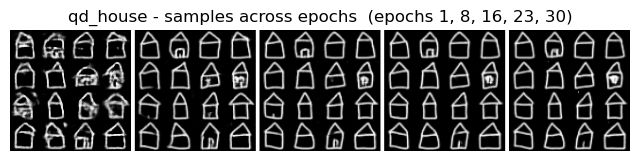

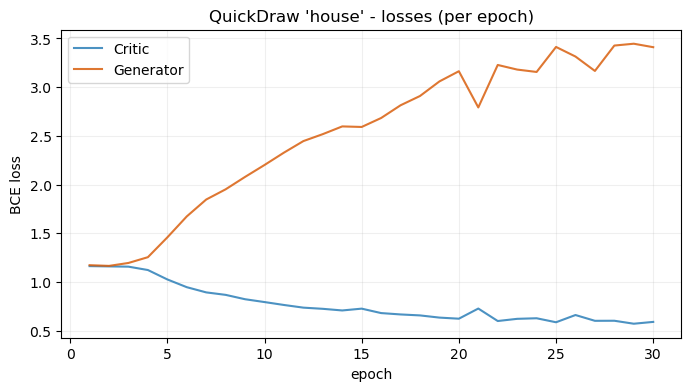

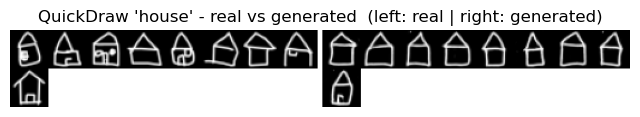

QuickDraw house: FID = 40.94


In [41]:
quickdraw_fid = {"birthday cake": cake_fid}
quickdraw_ink = {"birthday cake": ink_fraction(cake_uint8)}

for category in SKETCH_EXTRA_CATEGORIES:
    cat_uint8 = fetch_quickdraw(category)
    cat_images = bitmaps_to_signed(cat_uint8)
    quickdraw_ink[category] = ink_fraction(cat_uint8)
    cat_generator, cat_d, cat_g = fit_sketch_gan(cat_images, SKETCH_EPOCHS, category)
    plot_loss_history(cat_d, cat_g, f"QuickDraw '{category}' - losses (per epoch)", None)
    cat_fake = sample_sketch(cat_generator, 2000)
    show_real_fake(cat_images[:9], cat_fake[:9],
                   f"QuickDraw '{category}' - real vs generated", None)
    quickdraw_fid[category] = report_fid(frechet, cat_images, cat_fake, f"QuickDraw {category}")

In [ ]:
category_names = list(quickdraw_fid.keys())
fig, (fid_ax, ink_ax) = plt.subplots(1, 2, figsize=(12, 4))
fid_ax.bar(category_names, [quickdraw_fid[name] for name in category_names], color="#2c7fb8")
fid_ax.set_title("FID by category (lower is better)"); fid_ax.tick_params(axis="x", rotation=20)
ink_ax.bar(category_names, [quickdraw_ink[name] for name in category_names], color="#d95f0e")
ink_ax.set_title("Ink-density complexity proxy"); ink_ax.tick_params(axis="x", rotation=20)
fig.suptitle("QuickDraw extension: FID vs ink-density complexity")
plt.show()

print("QuickDraw per-category summary:")
for name in category_names:
    print(f"  {name:>14}: FID={quickdraw_fid[name]:.2f} | ink-density={quickdraw_ink[name]:.4f}")

## 2.3 - Notes and reflection

**Shape.** The generated cakes have a recognisable cake outline with candle-like marks on top in most of the samples, and the strokes are fairly clean. That fits the cake FID of 24.51, the best of the sketch categories. A few samples have small stroke artefacts, but the overall shape holds across the grid.

**Training behaviour.** Under the shared trainer the losses stayed stable through to the last epoch with neither network running away, which matches the clean, consistent samples in the final grid.

**FID vs complexity.** The three categories come out as cake 24.51, cat 30.52 and house 40.94, while the ink-density proxy is 0.198 for cake, 0.1985 for cat and 0.173 for house. So house is actually the *sparsest* category yet it scores the *worst* FID - the opposite of the "more ink means harder" idea I started with. My read is that ink density on its own is not a good difficulty predictor: a house is a few long, straight, precise lines that have to meet at clean corners, and getting that geometry exactly right is harder for the generator than the more forgiving, textured strokes of a cake or a cat. So stroke geometry matters more than the sheer amount of ink.